<a class="anchor" id="0"></a>
# **Classificador LightGBM em Python**

Olá, amigos,

Neste kernel, discutirei um dos algoritmos de aprendizado de máquina mais bem-sucedidos: o Classificador LightGBM. O LightGBM é um framework rápido, distribuído e de alto desempenho para boosting baseado em algoritmos de árvores de decisão, utilizado para tarefas de ranking, classificação e muitas outras aplicações de aprendizado de máquina. Ele tem ajudado muitos competidores a vencer competições de ciência de dados no Kaggle.

Então, vamos começar!


# **Sumário** <a class="anchor" id="0.1"></a>

- [1. Introdução ao LightGBM](#1)
- [2. Intuição do LightGBM](#2)
- [3. XGBoost Vs LightGBM](#3)
- [4. Parâmetros do LightGBM](#4)
   - [4.1 Parâmetros de Controle](#4.1)
   - [4.2 Parâmetros Principais](#4.2)
   - [4.3 Parâmetro de Métrica](#4.3)
   - [4.4 Parâmetro de Entrada/Saída](#4.4)
- [5. Implementação do LightGBM em Python](#5)
- [6. Ajuste de Parâmetros do LightGBM](#6)
- [7. Referências](#7)


# **1. Introdução ao LightGBM** <a class="anchor" id="1"></a>

[Sumário](#0.1)

- [LightGBM](https://github.com/Microsoft/LightGBM) é um framework de gradient boosting que utiliza algoritmos de aprendizado baseados em árvores. Ele foi projetado para ser distribuído e eficiente, oferecendo as seguintes vantagens:

  - Treinamento mais rápido e maior eficiência.
  - Menor uso de memória.
  - Melhor precisão.
  - Suporte a aprendizado paralelo e via GPU.
  - Capacidade de lidar com dados em larga escala.

- Atualmente, algoritmos de aprendizado baseados em árvores de decisão dominam as competições do Kaggle. As soluções vencedoras nessas competições geralmente utilizam um algoritmo chamado **XGBoost**.

- Há alguns anos, a Microsoft anunciou seu framework de gradient boosting chamado LightGBM. Hoje em dia, ele tem ganhado destaque nas máquinas de gradient boosting. Os competidores do Kaggle começaram a usar o LightGBM mais do que o XGBoost. O LightGBM é 6 vezes mais rápido que o XGBoost.

- LightGBM é um algoritmo relativamente novo e possui uma longa lista de parâmetros disponíveis na [documentação do LightGBM](https://github.com/microsoft/LightGBM).

- O tamanho dos datasets está crescendo rapidamente, tornando muito difícil para algoritmos tradicionais de ciência de dados fornecer resultados precisos. O LightGBM recebe o prefixo **Light** por sua alta velocidade. **O LightGBM pode lidar com grandes volumes de dados e consome menos memória para rodar**.

- Outro motivo pelo qual o LightGBM é tão popular é seu foco na precisão dos resultados. O LGBM também suporta aprendizado via GPU, o que faz com que cientistas de dados o utilizem amplamente para o desenvolvimento de aplicações em ciência de dados.

- Não é recomendável usar o LGBM em conjuntos de dados pequenos. O LightGBM é sensível a overfitting e pode facilmente se ajustar demais a dados pequenos.


# **2. Intuição do LightGBM** <a class="anchor" id="2"></a>

[Sumário](#0.1)

- LightGBM é um framework de gradient boosting que utiliza algoritmo de aprendizado baseado em árvores.

- A documentação do LightGBM afirma que:

  `LightGBM cresce a árvore verticalmente, enquanto outros algoritmos baseados em árvore crescem horizontalmente.  
  Isso significa que o LightGBM cresce a árvore folha a folha, enquanto outros algoritmos crescem nível a nível.  
  Ele escolhe a folha com a maior variação de perda (delta loss) para crescer. Ao crescer a mesma folha,  
  o algoritmo folha a folha pode reduzir mais a perda do que um algoritmo nível a nível.`

- Portanto, é importante entendermos a diferença entre o crescimento de árvore folha a folha e o crescimento nível a nível.


## **2.1 Crescimento de árvore folha a folha** <a class="anchor" id="2.1"></a>

[Sumário](#0.1)

- O crescimento de árvore folha a folha pode ser melhor explicado com a seguinte imagem:


![Leaf-wise tree growth](../../img/leaf-wise-tree-growth.png)

## **2.2 Crescimento de árvore nível a nível** <a class="anchor" id="2.2"></a>

[Sumário](#0.1)

- A maioria dos algoritmos de aprendizado de árvore de decisão cresce a árvore por níveis (profundidade).

- O crescimento de árvore nível a nível pode ser melhor explicado com a seguinte imagem:


![Leaf-wise tree growth](../../img/level-wise-tree-growth.png)

## **Pontos importantes sobre o crescimento da árvore**

- Se crescermos a árvore completa, os métodos **best-first (folha a folha)** e **depth-first (nível a nível)** resultarão na mesma árvore. A diferença está na ordem em que a árvore é expandida. Como normalmente não crescemos as árvores até a profundidade máxima, a ordem importa.

- A aplicação de critérios de parada antecipada e métodos de poda pode resultar em árvores bastante diferentes. Como o método folha a folha escolhe divisões com base na contribuição delas para a perda global e não apenas na perda ao longo de um ramo específico, ele frequentemente (mas não sempre) aprende árvores com menor erro "mais rápido" do que o método nível a nível.

- Para um número pequeno de nós, o método folha a folha provavelmente terá desempenho melhor que o nível a nível. À medida que adicionamos mais nós, sem parar ou podar, eles convergirão para o mesmo desempenho, pois acabarão construindo literalmente a mesma árvore.


# **3. XGBoost Vs LightGBM** <a class="anchor" id="3"></a>

[Sumário](#0.1)

- [XGBoost](https://github.com/dmlc/xgboost) é um algoritmo de aprendizado de máquina muito rápido e preciso. Porém, agora ele vem sendo desafiado pelo [LightGBM](https://github.com/microsoft/LightGBM) — que é ainda mais rápido, com precisão comparável e oferece mais hiperparâmetros para os usuários ajustarem.

- A principal diferença na velocidade está no fato de que **o XGBoost divide os nós da árvore um nível por vez**, enquanto **o LightGBM faz isso um nó por vez**.

- Por isso, os desenvolvedores do XGBoost melhoraram seu algoritmo para acompanhar o LightGBM, permitindo que os usuários também executem o XGBoost no modo split-by-leaf `(grow_policy = ‘lossguide’)`. Com essa melhoria, o XGBoost ficou muito mais rápido, mas o LightGBM ainda é cerca de 1,3 a 1,5 vezes mais rápido que o XGBoost.

- Outra diferença entre XGBoost e LightGBM é que o XGBoost possui um recurso que o LightGBM não tem — **restrição monotônica**. Esse recurso pode sacrificar um pouco a precisão do modelo e aumentar o tempo de treinamento, mas pode melhorar a interpretabilidade do modelo.


# **4. Parâmetros do LightGBM** <a class="anchor" id="4"></a>

[Sumário](#0.1)

- O [LightGBM](https://github.com/microsoft/LightGBM) oferece mais de 100 [parâmetros do LightGBM](https://github.com/microsoft/LightGBM/blob/master/docs/Parameters.rst).

- É muito importante conhecer alguns parâmetros básicos do LightGBM.

- Portanto, nesta seção, discutirei alguns parâmetros básicos do LightGBM.


## **4.1 Parâmetros de Controle** <a class="anchor" id="4.1"></a>

[Sumário](#0.1)

- **max_depth**: Descreve a profundidade máxima da árvore. Este parâmetro é usado para controlar o overfitting do modelo. Se você perceber que seu modelo está com overfitting, deve diminuir o max_depth.

- **min_data_in_leaf**: É o número mínimo de registros que uma folha pode ter. O valor padrão é 20, considerado ótimo. Também é usado para lidar com overfitting.

- **feature_fraction**: Usado quando o boosting é do tipo random forest. Um valor de 0,8 significa que o LightGBM selecionará aleatoriamente 80% das características em cada iteração para construir as árvores.

- **bagging_fraction**: Especifica a fração dos dados a ser usada em cada iteração, geralmente para acelerar o treinamento e evitar overfitting.

- **early_stopping_round**: Esse parâmetro ajuda a acelerar a análise. O treinamento do modelo será interrompido se uma métrica de um dos dados de validação não melhorar nas últimas `early_stopping_round` iterações. Isso reduz iterações excessivas.

- **lambda**: Especifica a regularização. O valor típico varia de 0 a 1.

- **min_gain_to_split**: Define o ganho mínimo necessário para realizar uma divisão. Pode ser usado para controlar o número de divisões úteis na árvore.

- **max_cat_group**: Quando o número de categorias é grande, encontrar o ponto de divisão pode levar facilmente ao overfitting. Por isso, o LightGBM agrupa as categorias em ‘max_cat_group’ grupos e encontra os pontos de divisão nas fronteiras desses grupos. Valor padrão: 64.


## **4.2 Parâmetros Principais** <a class="anchor" id="4.2"></a>

[Sumário](#0.1)

- **task**: Especifica a tarefa que você quer realizar com os dados. Pode ser `train` (treinamento) ou `predict` (previsão).

- **application**: Este é o parâmetro mais importante e define a aplicação do seu modelo, se é um problema de regressão ou de classificação. Por padrão, o LightGBM considera o modelo como regressão.

  - **regression**: para regressão
  - **binary**: para classificação binária
  - **multiclass**: para problemas de classificação multiclasse

- **boosting**: Define o tipo de algoritmo que você quer usar, padrão = `gbdt`.

  - **gbdt**: Gradient Boosting Decision Tree tradicional
  - **rf**: random forest
  - **dart**: Dropouts meet Multiple Additive Regression Trees
  - **goss**: Gradient-based One-Side Sampling

- **num_boost_round**: Número de iterações de boosting, tipicamente 100 ou mais.

- **learning_rate**: Determina o impacto de cada árvore no resultado final. O GBM começa com uma estimativa inicial que é atualizada com a saída de cada árvore. O parâmetro de aprendizado controla a magnitude dessa mudança nas estimativas. Valores típicos: 0.1, 0.001, 0.003…

- **num_leaves**: Número de folhas na árvore completa, padrão: 31.

- **device**: Padrão: `cpu`. Também pode ser configurado para `gpu`.


## **4.3 Parâmetro de Métrica** <a class="anchor" id="4.3"></a>

[Sumário](#0.1)

- **metric**: novamente, um dos parâmetros importantes, pois especifica a função de perda para a construção do modelo. Abaixo estão algumas perdas gerais para regressão e classificação.

  - **mae**: erro absoluto médio (mean absolute error)
  - **mse**: erro quadrático médio (mean squared error)
  - **binary_logloss**: perda para classificação binária
  - **multi_logloss**: perda para classificação multiclasse


## **4.4 Parâmetro de Entrada/Saída (IO)** <a class="anchor" id="4.4"></a>

[Sumário](#0.1)

- **max_bin**: Indica o número máximo de bins nos quais o valor da característica será agrupado.

- **categorical_feature**: Indica o índice das características categóricas. Por exemplo, se `categorical_features=0,1,2`, então as colunas 0, 1 e 2 são variáveis categóricas.

- **ignore_column**: Funciona como o `categorical_features`, mas ao invés de considerar colunas específicas como categóricas, essas colunas serão completamente ignoradas.

- **save_binary**: Se você está lidando com o tamanho da memória do seu arquivo de dados, especifique esse parâmetro como ‘True’. Isso salvará o dataset em um arquivo binário, o que acelerará o tempo de leitura dos dados nas próximas vezes.


# **5. Implementação do LightGBM em Python** <a class="anchor" id="5"></a>

[Sumário](#0.1)


## Importar bibliotecas

In [34]:
import numpy as np # álgebra linear
import pandas as pd # processamento de dados, leitura de arquivos CSV (por exemplo: pd.read_csv)
import matplotlib.pyplot as plt # visualização de dados
import seaborn as sns # visualização estatística de dados
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')

## Lendo a base

In [35]:
df = pd.read_csv('C:/Users/ofici/OneDrive/Documentos/estudos_prova_cientista/modelos/bases/breast_cancer_data.csv')

In [36]:
# Dimensão da base de dados
df.shape

(569, 6)

In [37]:
# Top 5 linhas da base de dados
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [38]:
# explorando a varoável alvo (target)

df['diagnosis'].value_counts()

diagnosis
1    357
0    212
Name: count, dtype: int64

A variável alvo é diagnosis. Ela contém 2 valores — 0 e 1.

0 representa previsão negativa e 1 representa previsão positiva.

Podemos ver que o problema é uma tarefa de classificação binária.

# Declarar vetor de atributos e variável alvo

In [39]:
X = df[['mean_radius','mean_texture','mean_perimeter','mean_area','mean_smoothness']]
y = df['diagnosis']

In [ ]:
# Separando os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

# Verificando as dimensões dos conjuntos de treino e teste
X_train.shape, X_test.shape

((381, 5), (188, 5))

## **Desenvolvimento e Treinamento do Modelo LightGBM**

- Precisamos converter nossos dados de treinamento para o formato de dataset do LightGBM (isso é obrigatório para o treinamento do LightGBM).

- Após criar o dataset necessário, criamos um dicionário em Python com os parâmetros e seus respectivos valores.

- A precisão do modelo depende dos valores fornecidos para os parâmetros.

- No bloco final do código, simplesmente treinamos o modelo com 100 iterações.


In [41]:
# import LGBM

import lightgbm as lgb
from sklearn.model_selection import cross_val_score, KFold

# instanciar o modelo LGBM 
clf = lgb.LGBMClassifier()

# KFold cross-validation com 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando o modelo com cross-validation (usando acurácia)
cv_scores = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')

print("Acurácias em cada fold:", cv_scores)
print("Acurácia média (cross-validation): {:.4f}".format(cv_scores.mean()))

# ajustar o modelo (fit the model)
clf.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 191, number of negative: 113
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628289 -> initscore=0.524886
[LightGBM] [Info] Start training from score 0.524886
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Prever os resultados do conjunto de treino e teste

In [42]:
y_pred = clf.predict(X_test)
y_pred_train = clf.predict(X_train)

y_pred_proba = clf.predict_proba(X_test)[:, 1]
y_pred_proba_train = clf.predict_proba(X_train)[:, 1]

![Métricas de Avaliação de Classificadores](../../img/metricas-avaliacao-modelos-classificacao.png)

In [43]:
# Importando libs das métricas de avaliação do modelo

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Exibir a acurácia do modelo LGBM
print('Acurácia do modelo LGBM: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
print('Precisão do modelo LGBM: {0:0.4f}'.format(precision_score(y_test, y_pred, average='weighted')))
print('Recall do modelo LGBM: {0:0.4f}'.format(recall_score(y_test, y_pred, average='weighted')))
print('F1-score do modelo LGBM: {0:0.4f}'.format(f1_score(y_test, y_pred, average='weighted')))

auc_roc = roc_auc_score(y_test, y_pred_proba)
print('Gini do modelo LGBM: {0:0.4f}'.format(2 * auc_roc - 1))

Acurácia do modelo LGBM: 0.9415
Precisão do modelo LGBM: 0.9438
Recall do modelo LGBM: 0.9415
F1-score do modelo LGBM: 0.9419
Gini do modelo LGBM: 0.9741


In [44]:
# Exibir a acurácia do modelo LGBM
print('Acurácia do modelo LGBM (treino): {0:0.4f}'.format(accuracy_score(y_train, y_pred_train)))
print('Precisão do modelo LGBM (treino): {0:0.4f}'.format(precision_score(y_train, y_pred_train, average='weighted')))
print('Recall do modelo LGBM (treino): {0:0.4f}'.format(recall_score(y_train, y_pred_train, average='weighted')))
print('F1-score do modelo LGBM (treino): {0:0.4f}'.format(f1_score(y_train, y_pred_train, average='weighted')))

auc_roc = roc_auc_score(y_train, y_pred_proba_train)
print('Gini do modelo LGBM (treino): {0:0.4f}'.format(2 * auc_roc - 1))

Acurácia do modelo LGBM (treino): 1.0000
Precisão do modelo LGBM (treino): 1.0000
Recall do modelo LGBM (treino): 1.0000
F1-score do modelo LGBM (treino): 1.0000
Gini do modelo LGBM (treino): 1.0000


### Verificar sobreajuste (overfitting) e subajuste (underfitting)

In [45]:
# exibir os scores no conjunto de treino e no conjunto de teste

print('Score no conjunto de treino: {:.4f}'.format(clf.score(X_train, y_train)))
print('Score no conjunto de teste: {:.4f}'.format(clf.score(X_test, y_test)))

Score no conjunto de treino: 1.0000
Score no conjunto de teste: 0.9415


## Matriz de Confusão

In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm)
print('\nTrue Positives(TP) = ', cm[0,0])
print('\nTrue Negatives(TN) = ', cm[1,1])
print('\nFalse Positives(FP) = ', cm[0,1])
print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[ 64   3]
 [  8 113]]

True Positives(TP) =  64

True Negatives(TN) =  113

False Positives(FP) =  3

False Negatives(FN) =  8


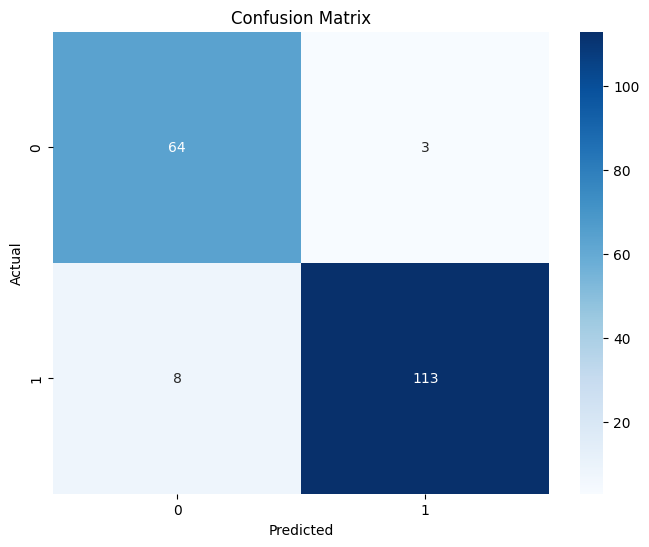

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        67
           1       0.97      0.93      0.95       121

    accuracy                           0.94       188
   macro avg       0.93      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



In [49]:
feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_scores

mean_smoothness    525
mean_texture       512
mean_perimeter     366
mean_radius        262
mean_area          207
dtype: int32

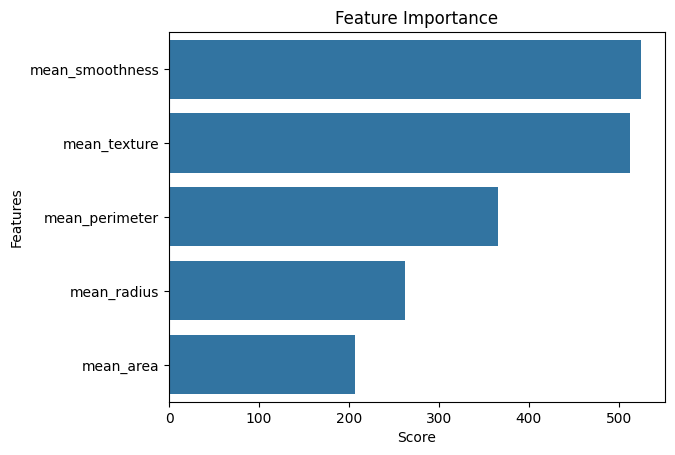

In [50]:
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Score')
plt.ylabel('Features')
plt.title("Feature Importance")
plt.show()

# **6. Ajuste de Parâmetros do LightGBM** <a class="anchor" id="6"></a>

[Sumário](#0.1)

- Nesta seção, discutirei algumas dicas para melhorar a eficiência do modelo LightGBM.

- O conjunto de práticas a seguir pode ser usado para melhorar a eficiência do seu modelo:

  - 1 **num_leaves**: Este é o principal parâmetro para controlar a complexidade do modelo de árvore. Idealmente, o valor de `num_leaves` deve ser menor ou igual a 2^(max_depth). Valores maiores que isso resultarão em overfitting.

  - 2 **min_data_in_leaf**: Definir este parâmetro com um valor alto pode evitar que a árvore cresça muito profunda, mas pode causar underfitting. Na prática, definir valores na ordem de centenas ou milhares é suficiente para um conjunto de dados grande.

  - 3 **max_depth**: Também podemos usar o parâmetro `max_depth` para limitar explicitamente a profundidade da árvore.


## **Para Maior Velocidade**

- Use bagging configurando `bagging_fraction` e `bagging_freq`.
- Utilize subamostragem de características ajustando `feature_fraction`.
- Use um valor pequeno para `max_bin`.
- Configure `save_binary` para acelerar o carregamento dos dados em futuros treinamentos.


## **Para Melhor Precisão**

- Use um valor grande para `max_bin` (pode ser mais lento).
- Use um `learning_rate` pequeno com um `num_iterations` grande.
- Utilize um valor alto para `num_leaves` (pode causar overfitting).
- Utilize um conjunto de dados de treinamento maior.
- Experimente o método `dart`.
- Tente usar as características categóricas diretamente.


## **Para Lidar com Overfitting**

- Use um valor pequeno para `max_bin`.
- Use um valor pequeno para `num_leaves`.
- Configure `min_data_in_leaf` e `min_sum_hessian_in_leaf`.
- Utilize bagging configurando `bagging_fraction` e `bagging_freq`.
- Faça subamostragem de características ajustando `feature_fraction`.
- Use um conjunto de dados de treinamento maior.
- Experimente `lambda_l1`, `lambda_l2` e `min_gain_to_split` para regularização.
- Tente usar `max_depth` para evitar que a árvore cresça muito profunda.
